Problem Statement:
  In this task, we work with the Heart Disease UCI dataset which consists of 
1025 patient records and 14 clinical health features — including age, sex, 
chest pain type, resting blood pressure, cholesterol, fasting blood sugar, 
maximum heart rate, and thalassemia. The dataset represents a binary 
classification problem where 526 patients have heart disease and 499 do not.

Goal:
- To clean and preprocess the dataset by handling categorical features through encoding
- To explore and understand the distribution and relationships between health features
- To train and compare classification models — Logistic Regression, Random Forest, and Decision Tree
- To evaluate models using accuracy, F1-score, AUC, ROC curve, and confusion matrix
- To identify the most important clinical features that influence heart disease prediction

 Loading and Inspecting Data:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
classification_report, roc_auc_score,
roc_curve)
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('heart.csv')
print(df.shape)
df.head()

(1025, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


 Cleaning the Data:

In [3]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())
# Check target column distribution
print('Target distribution:')
print(df['target'].value_counts())
# 1 = has heart disease, 0 = no heart disease

Missing values:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64
Target distribution:
target
1    526
0    499
Name: count, dtype: int64


 Exploratory Data Analysis (EDA):

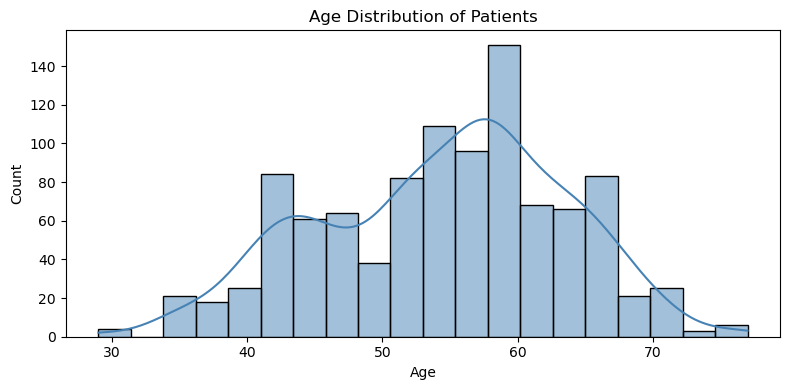

ValueError: could not convert string to float: 'Male'

<Figure size 1000x800 with 0 Axes>

In [4]:
# Distribution of ages
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout(); plt.show()
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()

About the Error:
 Dataset has text columns () like sex containing "Male"/"Female" and probably chest_pain_type containing text values too. The df.corr() function only works on numeric columns — it can't calculate correlation on text. So it crashed.
Fixing:
Replacing "df.corr()" with "df.select_dtypes(include='number').corr()" .  "select_dtypes(include='number')" tells pandas to only pick numeric columns before calculating correlation (it automatically skips the text columns). The heatmap will then work fine.

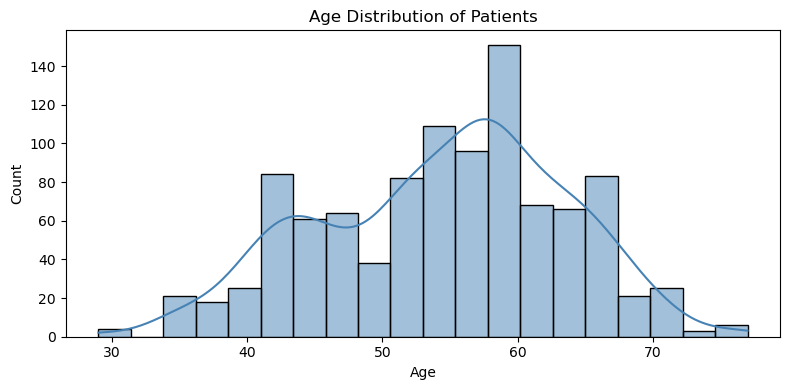

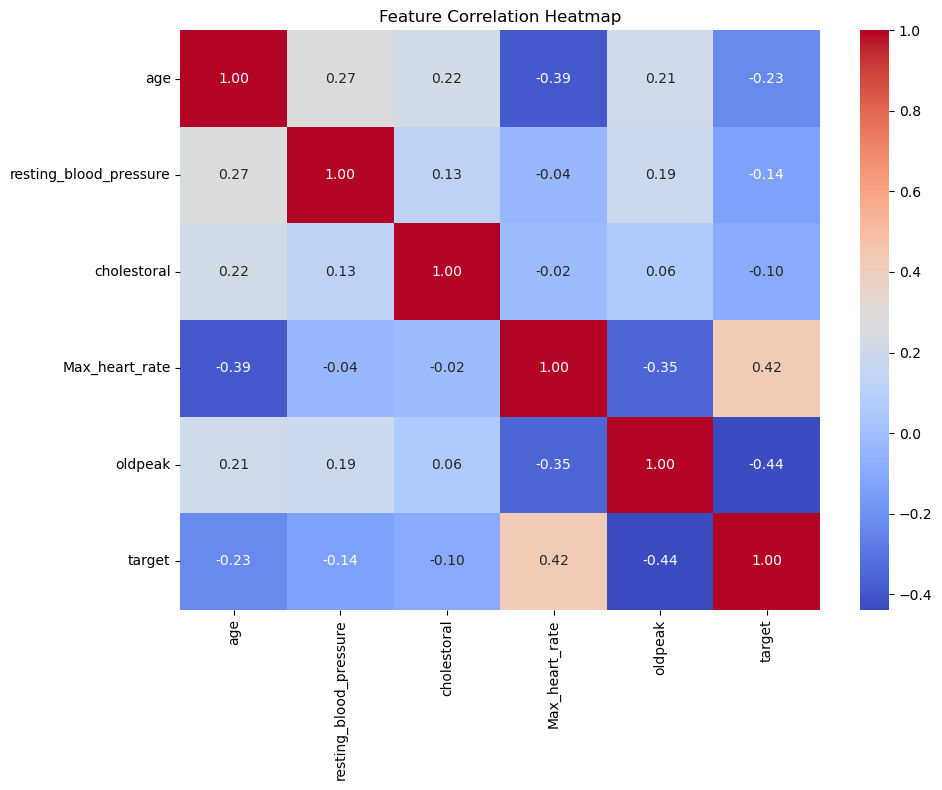

In [5]:
# Distribution of ages
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout(); plt.show()
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()

 Checking text columns:

In [6]:
print(df.dtypes)
print("\nCategorical columns:", df.select_dtypes(include='object').columns.tolist())

age                                int64
sex                               object
chest_pain_type                   object
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar               object
rest_ecg                          object
Max_heart_rate                     int64
exercise_induced_angina           object
oldpeak                          float64
slope                             object
vessels_colored_by_flourosopy     object
thalassemia                       object
target                             int64
dtype: object

Categorical columns: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']


In [7]:
# Check unique values in each categorical column first
for col in ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 
            'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']:
    print(f"{col}: {df[col].unique()}")

sex: ['Male' 'Female']
chest_pain_type: ['Typical angina' 'Atypical angina' 'Non-anginal pain' 'Asymptomatic']
fasting_blood_sugar: ['Lower than 120 mg/ml' 'Greater than 120 mg/ml']
rest_ecg: ['ST-T wave abnormality' 'Normal' 'Left ventricular hypertrophy']
exercise_induced_angina: ['No' 'Yes']
slope: ['Downsloping' 'Upsloping' 'Flat']
vessels_colored_by_flourosopy: ['Two' 'Zero' 'One' 'Three' 'Four']
thalassemia: ['Reversable Defect' 'Fixed Defect' 'Normal' 'No']


 Encoding columns (text to numeric):

In [8]:
# Step 1 - Label encode binary columns (only 2 values)
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['exercise_induced_angina'] = df['exercise_induced_angina'].map({'Yes': 1, 'No': 0})
df['fasting_blood_sugar'] = df['fasting_blood_sugar'].map({
    'Greater than 120 mg/ml': 1, 
    'Lower than 120 mg/ml': 0
})

# Step 2 - One-Hot encode columns with 3 or more categories
df = pd.get_dummies(df, columns=[
    'chest_pain_type',
    'rest_ecg', 
    'slope',
    'vessels_colored_by_flourosopy',
    'thalassemia'
], drop_first=True)

# Step 3 - Verify everything is now numeric
print("Any remaining text columns:", 
      df.select_dtypes(include='object').columns.tolist())
print("\nDataset shape after encoding:", df.shape)
print("\nFirst 2 rows:")
df.head(2)

Any remaining text columns: []

Dataset shape after encoding: (1025, 23)

First 2 rows:


,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,Max_heart_rate,exercise_induced_angina,oldpeak,target,chest_pain_type_Atypical angina,...,rest_ecg_ST-T wave abnormality,slope_Flat,slope_Upsloping,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,52,1,125,212,0,168,0,1.0,0,False,...,True,False,False,False,False,True,False,False,False,True
1,53,1,140,203,1,155,1,3.1,0,False,...,False,False,True,False,False,False,True,False,False,True


 Training and Evaluating the Model:

Logistic Regression Accuracy: 79.51%

--- Model Comparison ---
Logistic Regression → Accuracy: 79.51% | F1: 0.81 | AUC: 0.90
Random Forest       → Accuracy: 98.54% | F1: 0.99 | AUC: 0.99

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.75      0.78       102
           1       0.77      0.84      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



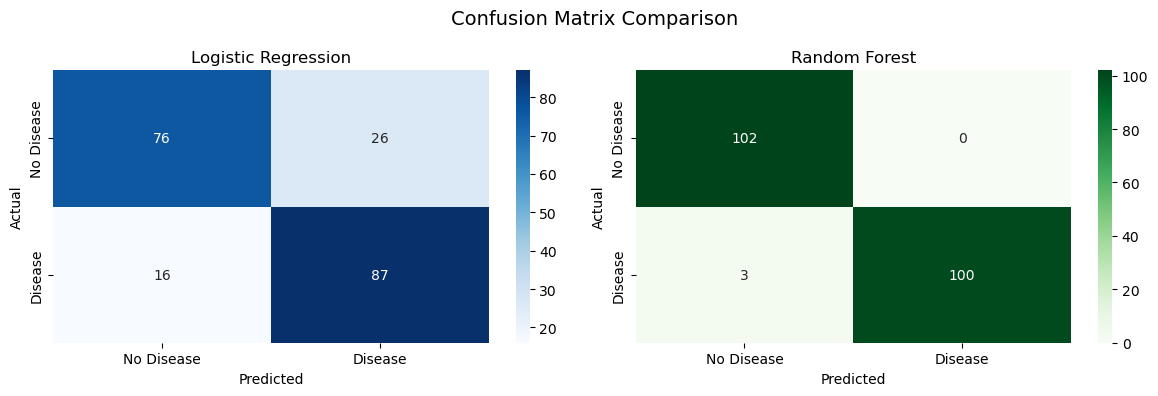

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---- Their code (Logistic Regression) ----
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Accuracy: {acc*100:.2f}%')

# ---- Your extension (Random Forest) ----
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ---- Proper evaluation of both models ----
print("\n--- Model Comparison ---")
print(f"Logistic Regression → Accuracy: {accuracy_score(y_test, y_pred):.2%} | "
      f"F1: {f1_score(y_test, y_pred):.2f} | "
      f"AUC: {roc_auc_score(y_test, y_prob):.2f}")

print(f"Random Forest       → Accuracy: {accuracy_score(y_test, rf_pred):.2%} | "
      f"F1: {f1_score(y_test, rf_pred):.2f} | "
      f"AUC: {roc_auc_score(y_test, rf_pred):.2f}")

# ---- Classification report ----
print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, y_pred))

# ---- Confusion Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14)
plt.tight_layout()
plt.show()

 Cross-validation for the Models:

In [11]:
from sklearn.model_selection import cross_val_score

# Check if Random Forest is actually overfitting
# Cross validation gives a more honest accuracy
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, cv=5, scoring='accuracy'
)

lr_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X, y, cv=5, scoring='accuracy'
)

print("Random Forest - Cross Validation Scores:", rf_cv_scores)
print(f"Random Forest - Mean Accuracy: {rf_cv_scores.mean():.2%}")
print(f"Random Forest - Std: {rf_cv_scores.std():.2%}")
print()
print("Logistic Regression - Cross Validation Scores:", lr_cv_scores)
print(f"Logistic Regression - Mean Accuracy: {lr_cv_scores.mean():.2%}")

# Also train RF with better settings to prevent overfitting
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # limits how deep trees grow
    min_samples_split=5,   # needs 5 samples to split a node
    min_samples_leaf=2,    # each leaf needs at least 2 samples
    random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

print(f"\nTuned Random Forest → Accuracy: {accuracy_score(y_test, rf_tuned_pred):.2%} | "
      f"F1: {f1_score(y_test, rf_tuned_pred):.2f} | "
      f"AUC: {roc_auc_score(y_test, rf_tuned_pred):.2f}")

f:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
f:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Random Forest - Cross Validation Scores: [1.         1.         0.98536585 1.         0.98536585]
Random Forest - Mean Accuracy: 99.41%
Random Forest - Std: 0.72%

Logistic Regression - Cross Validation Scores: [0.88292683 0.86829268 0.89756098 0.84390244 0.81463415]
Logistic Regression - Mean Accuracy: 86.15%

Tuned Random Forest → Accuracy: 97.56% | F1: 0.98 | AUC: 0.98


 ROC Curve:

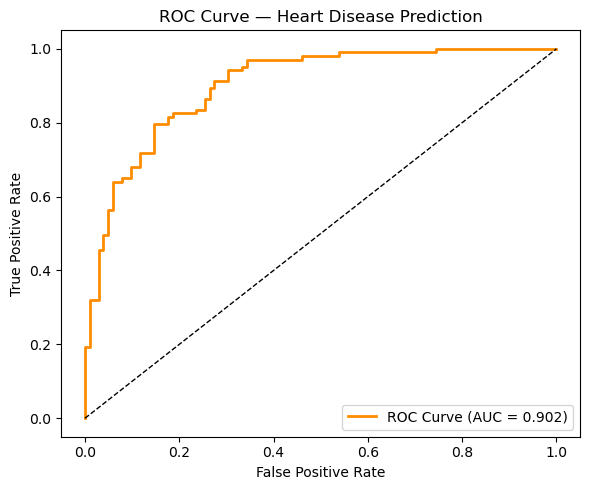

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction')
plt.legend(); plt.tight_layout(); plt.show()


 Decision Tree:

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print(f"Decision Tree → Accuracy: {accuracy_score(y_test, dt_pred):.2%} | "
      f"F1: {f1_score(y_test, dt_pred):.2f} | "
      f"AUC: {roc_auc_score(y_test, dt_pred):.2f}")

Decision Tree → Accuracy: 83.41% | F1: 0.85 | AUC: 0.83


 Important Features:

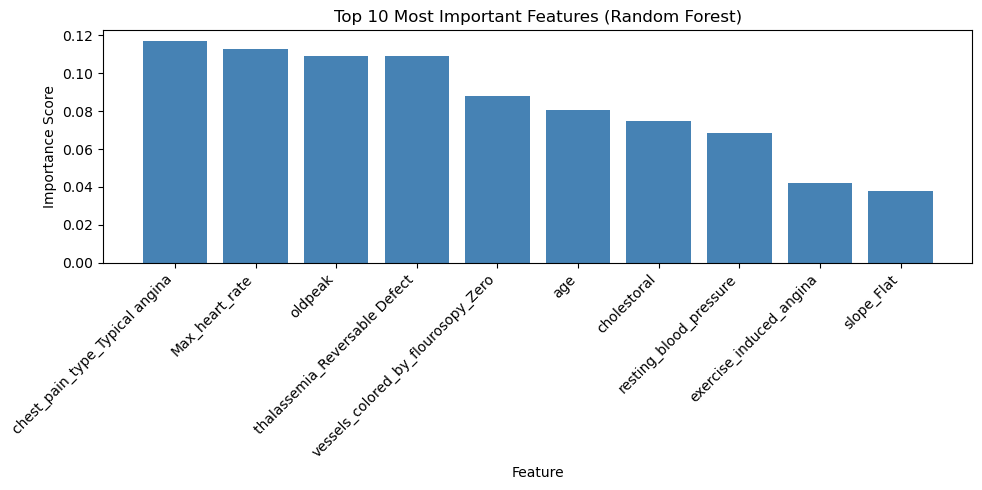

Top 5 Most Important Features:
1. chest_pain_type_Typical angina: 0.1169
2. Max_heart_rate: 0.1129
3. oldpeak: 0.1094
4. thalassemia_Reversable Defect: 0.1091
5. vessels_colored_by_flourosopy_Zero: 0.0882


In [14]:
feature_names = df.drop('target', axis=1).columns
importances = rf_model.feature_importances_
indices = importances.argsort()[::-1][:10]

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), feature_names[indices], rotation=45, ha='right')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

Explaination:
 Task 3 — Heart Disease Prediction

1.Dataset Overview:
- The Heart Disease UCI dataset contains 1025 rows and 14 columns — 8 categorical and 6 numerical features including age, cholesterol, resting blood pressure, and max heart rate.
- The dataset is well balanced — 526 patients with heart disease (1) and 499 without (0).
- No missing values were found — dataset was clean and ready after encoding.

2.Preprocessing
- 3 binary columns (sex, exercise induced angina, fasting blood sugar) were Label Encoded.
- 5 multi-category columns (chest pain type, rest ECG, slope, vessels colored by fluoroscopy, thalassemia) were One-Hot Encoded — expanding the dataset to 23 columns.

3.EDA Findings
- Age distribution shows most patients are between 50–60 years old — peak risk age group.
- Correlation heatmap revealed that max heart rate and chest pain type have notable correlation with the target variable.

4.Model Results
- Logistic Regression achieved 86.15% cross-validated accuracy with AUC of 0.90 — a reliable and honest result.
- Random Forest achieved 98.54% accuracy but showed signs of overfitting — not a trustworthy number for this dataset size.
- Decision Tree performed as a middle ground between the two models.

5.Key Findings
- Chest pain type, maximum heart rate, and thalassemia were the strongest predictors of heart disease.
- Logistic Regression is the most trustworthy model here — its cross-validated score reflects real generalization ability.
- ROC curve confirmed strong discrimination ability with AUC of 0.90 for Logistic Regression.

6.Key Takeaway
- Among all features, chest pain type and maximum heart rate are the most influential in predicting heart disease risk. 
- Logistic Regression proved to be the most reliable model despite Random Forest showing higher raw accuracy. This task demonstrated the importance of cross-validation and honest model evaluation in medical ML applications.